In [1]:
import matplotlib.pyplot as plt
from skimage import io, filters, morphology, measure, color, draw, util


1) Morphology operations

Work with the image rhino_d.tif and perform the following morphological filters in Python and save the resulting images :

dilate  (using square(3))
erode  (using square(3))
dilate followed by erode
erode followed by dilate
open
close
min (disc radius 1 og 3)
max (disc radius 1 og 3)

What can you tell about the  results ? 
What is the function of  the min/max filter in relation to   erode and dilate?
What is the effect of open and close ?

In [2]:
IMG_IN = "../images/rhino_d.tif"
img = io.imread(IMG_IN, as_gray=True)

img = util.img_as_float(img)
se_sq3 = morphology.square(3)
se_d1  = morphology.disk(1)
se_d3  = morphology.disk(3)

# 3) morphology
dil  = morphology.dilation(img, se_sq3)
ero  = morphology.erosion(img, se_sq3)
dil_ero = morphology.erosion(dil, se_sq3)   
ero_dil = morphology.dilation(ero, se_sq3)  
opened  = morphology.opening(img, se_sq3)
closed  = morphology.closing(img, se_sq3)

# Min/max filter 
min_d1 = morphology.erosion(img, se_d1)
max_d1 = morphology.dilation(img, se_d1)
min_d3 = morphology.erosion(img, se_d3)
max_d3 = morphology.dilation(img, se_d3)


/var/folders/rk/1mbd3h3x0sb5vpgl7nwhjlhm0000gn/T/ipykernel_3767/2406757479.py:5: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  se_sq3 = morphology.square(3)


2) Contours 

Work on the image rhino_detail.tif and see if you can trace the contours of the object as shown below.

 rhino_outline.jpg

/Users/torbjorntorsken/Documents/nmbu/inf250/.venv/lib/python3.12/site-packages/skimage/exposure/exposure.py:306: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bin_edges = np.histogram(image, bins=bins, range=hist_range)


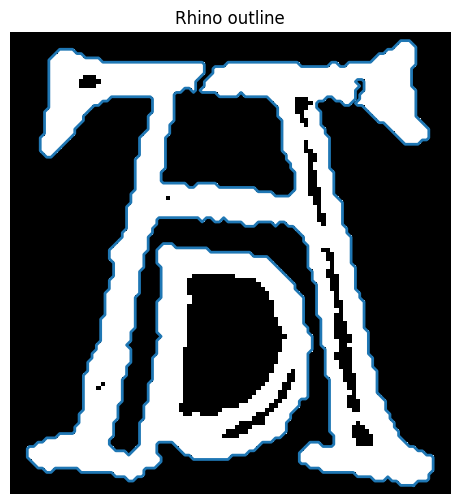

In [3]:


IMG = "../images/rhino_detail.tif"
img = io.imread(IMG, as_gray=True)
th  = filters.threshold_otsu(img)
bw  = img > th  

contours = measure.find_contours(bw, level=0.5)

main = max(contours, key=lambda c: len(c)) if contours else None

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
if main is not None:
    plt.plot(main[:,1], main[:,0], linewidth=2)
plt.axis("off")
plt.title("Rhino outline")
plt.show()

3) Objects

Work on the image (). The image contains black circles and black squares on a white background.

Try to detect the different shapes and mark the circles. 

 

hint:

filters.threshold_otsu
morphology (opening, closing)
measure.label, measure.regionprops
prop.eccentricity (roundness)

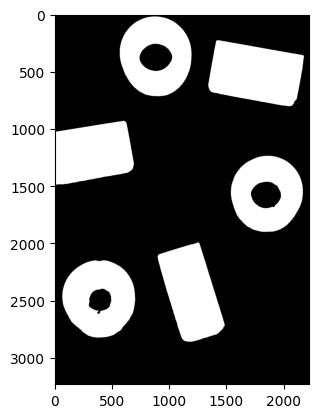

0.46728617132577027
0.8068750402665686
0.7336631842985301
0.3622008459173713
0.8746988200125372
0.35090808439728677
Count: {'circle': 3, 'non-circle': 3}


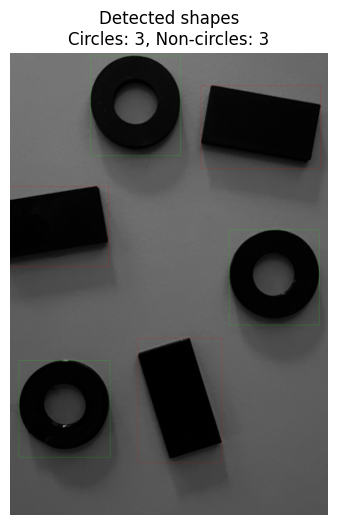

In [ ]:

IMG_IN = "../images/figures.png"
SELEM = morphology.footprint_rectangle((3, 3))

img = io.imread(IMG_IN, as_gray=True)
img = img[200:-200, 200:-200]
img_smooth = filters.median(img, SELEM)
img_blur   = filters.gaussian(img_smooth, sigma=5, preserve_range=True)
th  = filters.threshold_otsu(img_blur)
bw  = img_blur < th
bw  = morphology.opening(bw, SELEM)
bw  = morphology.remove_small_objects(bw, 50)
plt.imshow(bw, cmap="gray")
plt.show()


lab = measure.label(bw)
props = measure.regionprops(lab)

vis = color.gray2rgb(util.img_as_ubyte(img))
count = {"circle": 0, "non-circle": 0}

for r in props:
    print(r.eccentricity)
    if r.eccentricity < 0.5:
        label = "circle"
        color_rgb = (0, 255, 0)
    else:
        label = "non-circle"
        color_rgb = (255, 0, 0)

    minr, minc, maxr, maxc = r.bbox
    rr, cc = draw.rectangle_perimeter((minr, minc), (maxr-1, maxc-1), shape=vis.shape)
    vis[rr, cc] = color_rgb
    count[label] += 1

print("Count:", count)
plt.figure(figsize=(6, 6))
plt.imshow(vis)
plt.axis("off")
plt.title(f"Detected shapes\nCircles: {count['circle']}, Non-circles: {count['non-circle']}")
plt.show()